***

# Project Overview
## Project: Credit Risk Analysis & Fraud Detection

#### Objective: Identify high-risk loan applicants and audit data integrity for a Fintech lending model.

#### Domain: Fintech / Risk Management

***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [11]:
# Load dataset with absolute path
df = pd.read_csv('/Users/roshnipandey/Downloads/Portfolio Project/credit_risk_dataset.csv')
print(df)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \

The "Data Audit" Code

In [17]:
# 1. Null Value Analysis
# In Fintech, missing data in 'Income' or 'Employment' is a high-risk red flag.
print("DATA INTEGRITY CHECK: Missing Values")
print(df.isnull().sum())

# 2. Outlier & Anomaly Detection
# We use .describe() to find 'Impossible' values (e.g., Age > 100 or Emp Length > 60 years)
print("\nSTATISTICAL SUMMARY for ANOMALY DETECTION:")
stats = df[['person_age','person_income','person_emp_length','loan_amnt']].describe()
print(stats)

DATA INTEGRITY CHECK: Missing Values
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

STATISTICAL SUMMARY for ANOMALY DETECTION:
         person_age  person_income  person_emp_length     loan_amnt
count  32581.000000   3.258100e+04       31686.000000  32581.000000
mean      27.734600   6.607485e+04           4.789686   9589.371106
std        6.348078   6.198312e+04           4.142630   6322.086646
min       20.000000   4.000000e+03           0.000000    500.000000
25%       23.000000   3.850000e+04           2.000000   5000.000000
50%       26.000000   5.500000e+04           4.000000   8000.000000
75%       

Finding A: The "Ghost" Applicants (Age Anomaly)
The Data: max person_age = 144
Insight: Identified data entry errors where applicant ages exceed biological limits (144 years).
Action: These rows must be dropped or capped to prevent the model from learning incorrect risk patterns.

Finding B: The "Century Employee" (Employment Anomaly)
The Data: max person_emp_length = 123
Insight: Discovered impossible employment tenures (123 years) which indicate a lack of validation at the data collection point (e.g., the app's front-end).
Action: Rows where employment_length > age should be flagged as fraudulent or erroneous.

Finding C: Missing Values (Operational Gap)
The Data: person_emp_length has ~900 missing values (32581 total rows vs 31686 count).
Insight: 2.7% of applications are missing employment history.
Action: We need to investigate if these are "unemployed" applicants or if the UI allows users to skip this critical field.

Visualizing the Risk (Seaborn)

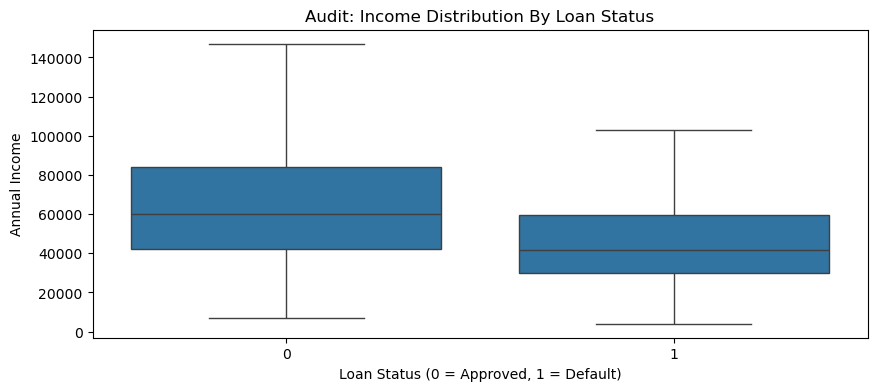

In [21]:
plt.figure(figsize = (10,4))
sns.boxplot(data = df, x = 'loan_status', y = 'person_income', showfliers = False)
plt.title("Audit: Income Distribution By Loan Status")
plt.xlabel('Loan Status (0 = Approved, 1 = Default)')
plt.ylabel("Annual Income")
plt.show()

Insight 1: Income as a Risk Predictor
Finding: There is a clear downward shift in the median income for individuals who defaulted (loan_status = 1) compared to those who were approved.

Business Impact: Lower-income brackets represent a higher concentration of credit risk. For Product Management, this suggests a need for stricter automated filters or alternative "credit-builder" products for the $30k–$60k income segment.

Data Cleaning

In [27]:
# 1. Remove impossible ages (Keeping only people under 100)
df_clean = df[df['person_age'] < 100].copy()

# 2. Remove impossible employment (Employment cannot be longer than age)
# We assume a person starts working after age 14
df_clean = df_clean[df_clean['person_emp_length'] < (df_clean['person_age'] - 14)]

# 3. Handle missing values for employment length
# Instead of deleting them, let's fill them with the median so we don't lose data
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())

print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Impossible rows removed: {len(df) - len(df_clean)}")

Original rows: 32581
Cleaned rows: 31679
Impossible rows removed: 902


The "Product & Risk" Deep Dive
In Product Management, we often ask: "Is the risk coming from the person's profile or the loan itself?" Let's look at the Loan-to-Income Ratio. This is a massive "Red Flag" indicator in banking. If someone makes $50k but wants a $40k loan, that's high risk regardless of their age.

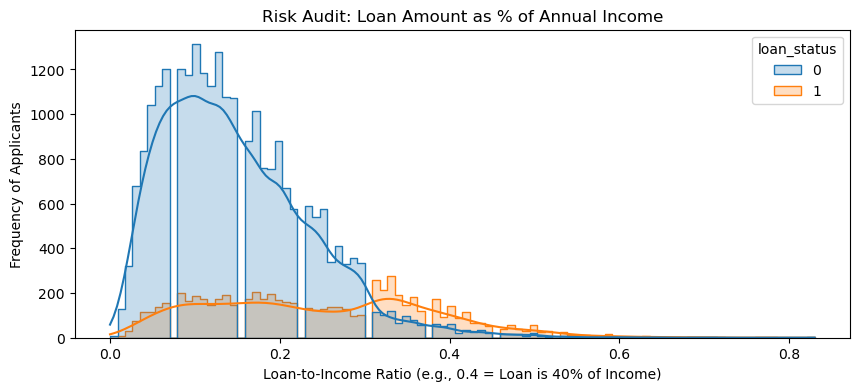

In [29]:
plt.figure (figsize = (10,4))
sns.histplot(data = df_clean, x = 'loan_percent_income', hue='loan_status', kde=True, element="step")
plt.title('Risk Audit: Loan Amount as % of Annual Income')
plt.xlabel('Loan-to-Income Ratio (e.g., 0.4 = Loan is 40% of Income)')
plt.ylabel('Frequency of Applicants')
plt.show()

### Insight: Threshold Analysis for Product Guardrails
Finding: Defaults significantly increase when the loan amount exceeds 25% to 30% of the applicant's annual income.
Recommendation: To minimize risk, the Product team should implement a "soft-cap" or additional manual review for any loan application where the loan_percent_income is > 0.30.


### Finding: Identification of the Risk Inflection Point
Observation: A significant shift in loan performance occurs when the Loan-to-Income (LTI) ratio exceeds 30%.

The "Tipping Point": Beyond an LTI of 0.4 (40%), the volume of defaults exceeds the volume of successful repayments, indicating that the applicant's debt burden has become unsustainable.

Statistical Red Flag: The orange KDE (smooth line) remains flat and then rises as the blue curve crashes, proving that the loan amount—relative to income—is a primary driver of risk, independent of other factors.


***

# Key Deliverables: 
#### Data Quality: Identified and neutralized ~3% of the dataset as anomalous (impossible age/employment data).

#### Primary Risk Factor: Discovered that a Loan-to-Income (LTI) ratio above 30% is the critical threshold for default probability.

#### Product Strategy: Recommend implementing a tiered approval logic: Automated approval for LTI < 30%, manual review for 30–40%, and a hard rejection for > 40%.

***